In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
import nltk
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import deepcut
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
data = pd.read_csv('resources/anthems.csv')

In [3]:
data.head()

,Country,Alpha-2,Alpha-3,Continent,Anthem
0,Albania,AL,ALB,Europe,"Around our flag we stand united, With one wish..."
1,Armenia,AM,ARM,Europe,"Our Fatherland, free, independent, That has fo..."
2,Austria,AT,AUT,Europe,"Land of mountains, land by the river, Land of ..."
3,Azerbaijan,AZ,AZE,Europe,"Azerbaijan, Azerbaijan! The glorious Fatherlan..."
4,Belarus,BY,BLR,Europe,"We, Belarusians, are peaceful people, Wholehea..."


# Check for missing value and Outliers

In [4]:
df = pd.DataFrame(data, columns=["Country", "Anthem"])

In [5]:
df.isna().sum()

Country    0
Anthem     0
dtype: int64

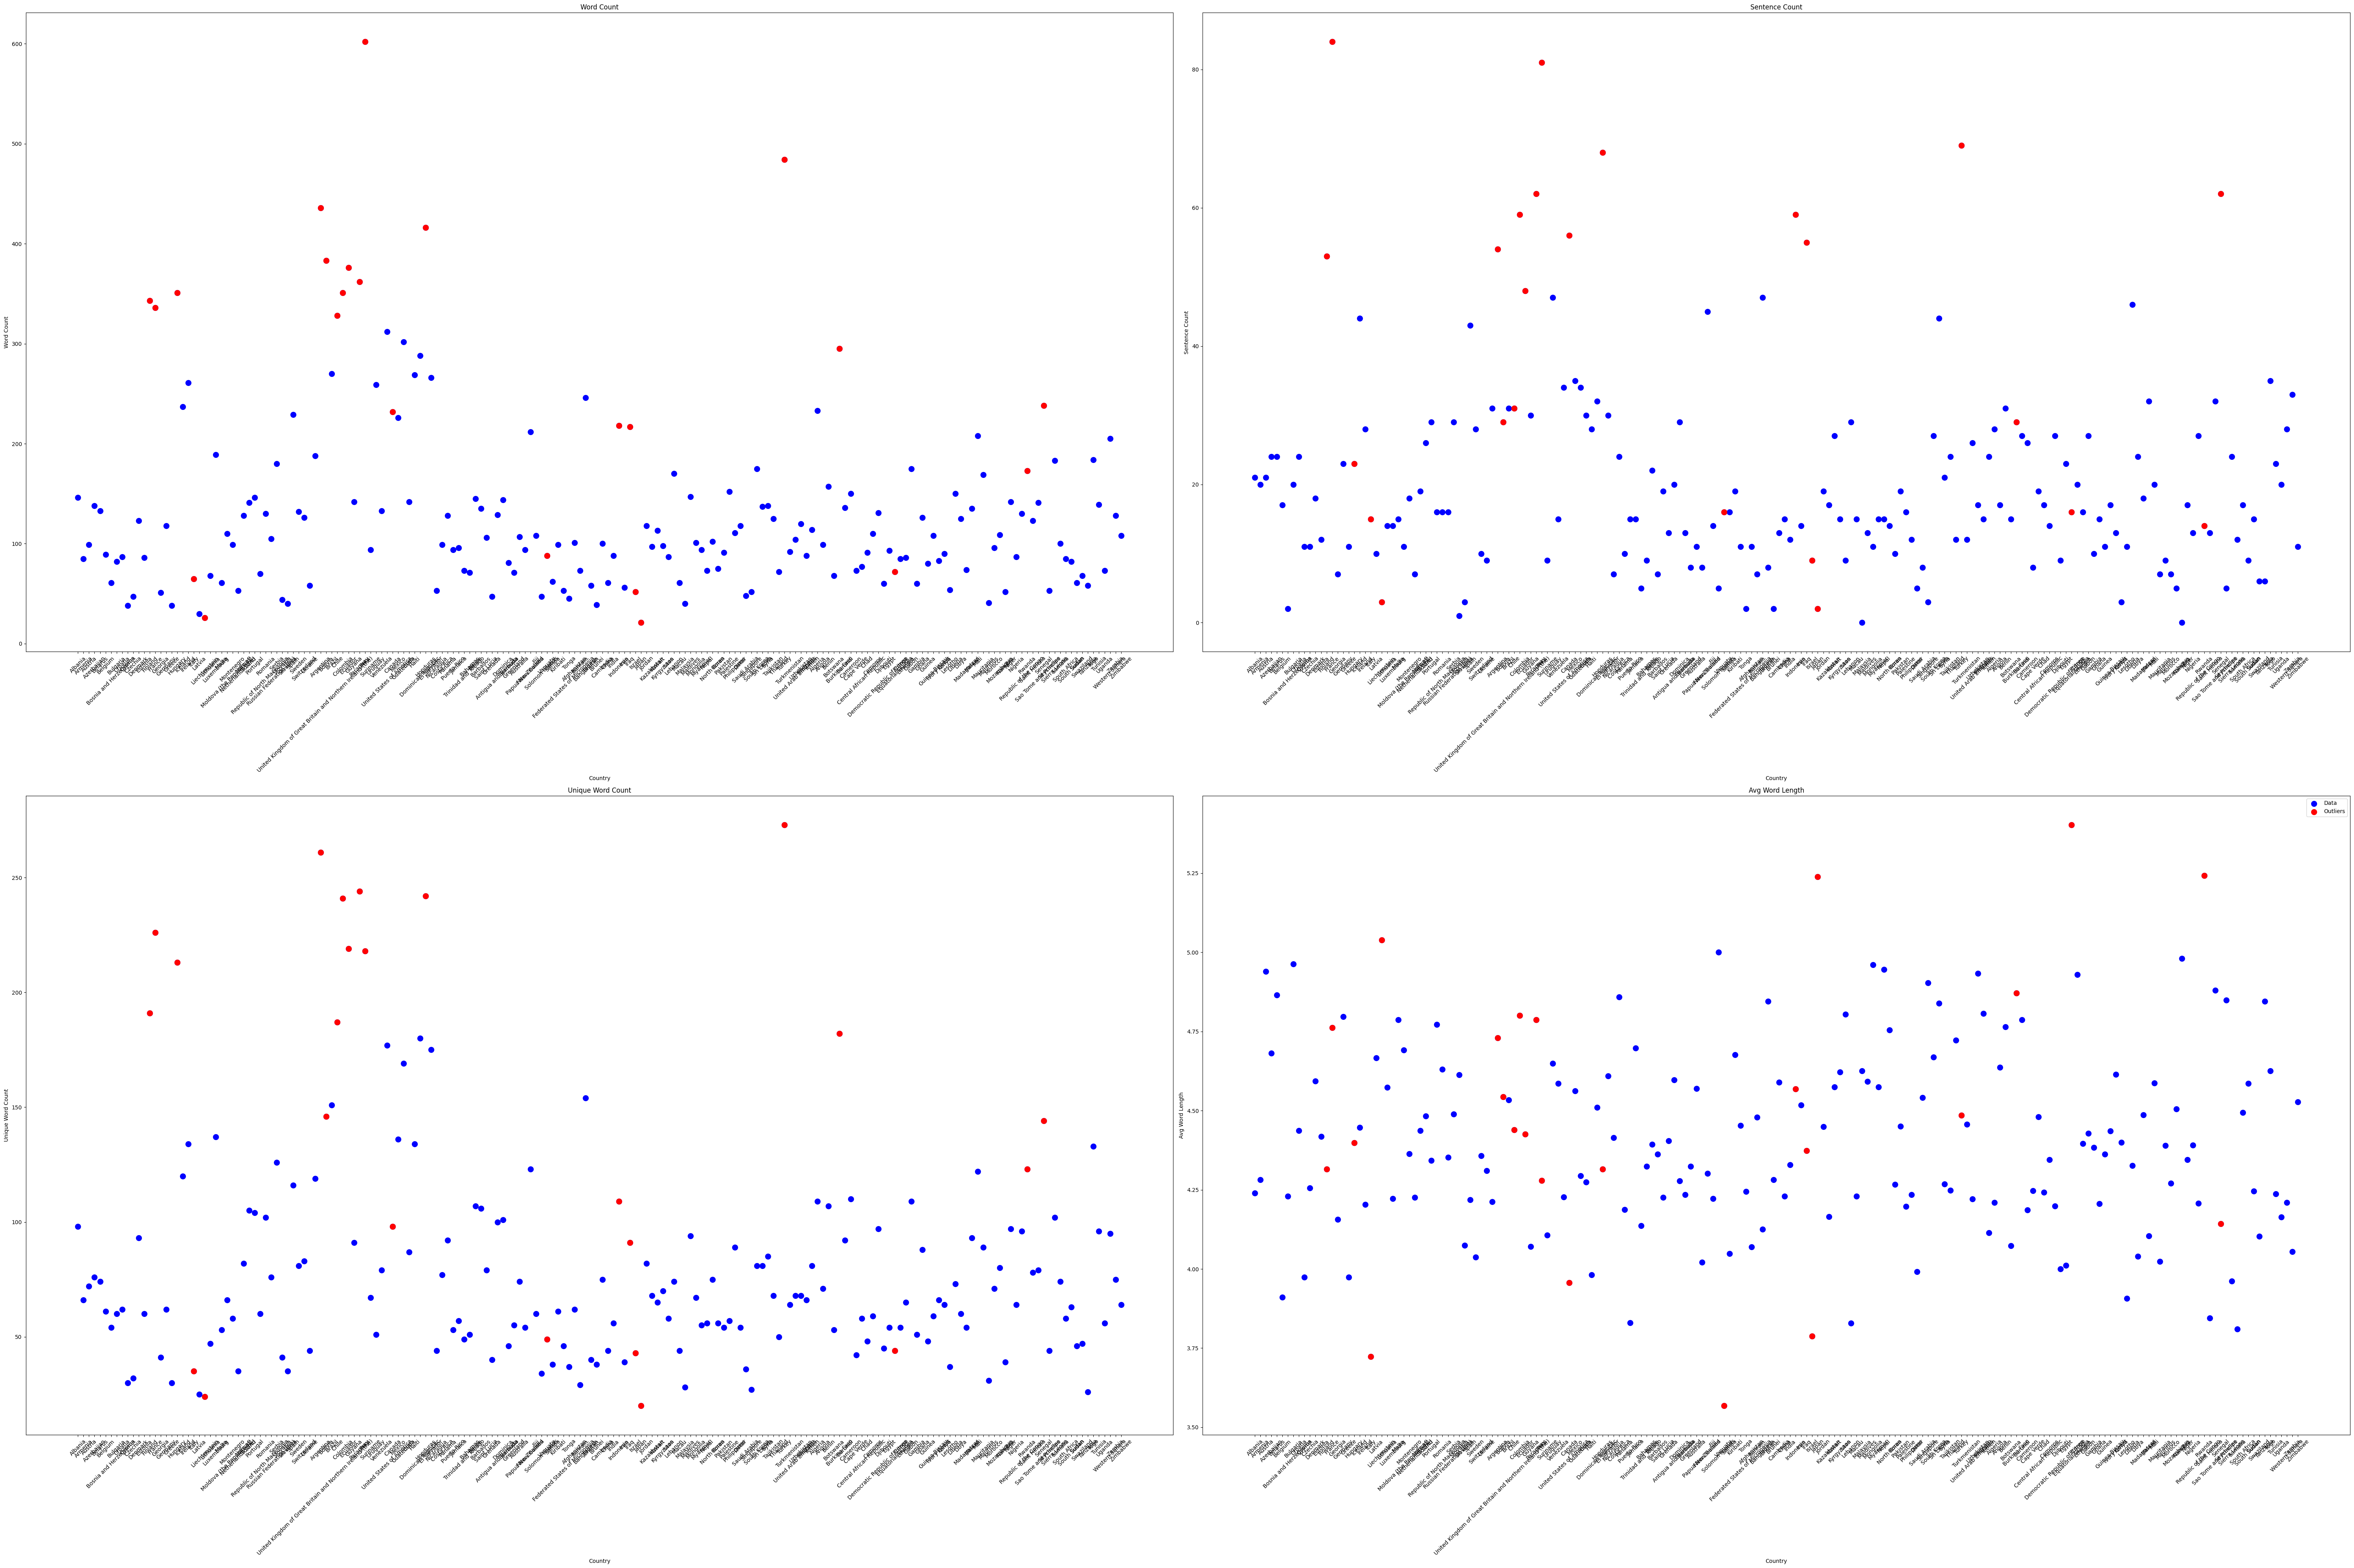

In [6]:
def extract_features(text):
    text_clean = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text_clean.split()
    
    word_count = len(words)
    sentence_count = text.count('.') + text.count('!') + text.count('?') + text.count(',')
    unique_word_count = len(set(words))
    avg_word_length = np.mean([len(word) for word in words]) if words else 0
    
    return word_count, sentence_count, unique_word_count, avg_word_length

df[['Word Count', 'Sentence Count', 'Unique Word Count', 'Avg Word Length']] = df['Anthem'].apply(lambda x: pd.Series(extract_features(x)))

features = ['Word Count', 'Sentence Count', 'Unique Word Count', 'Avg Word Length']
z_scores = np.abs((df[features] - df[features].mean()) / df[features].std())

outliers = (z_scores > 2).any(axis=1)

plt.figure(figsize=(60, 40))

for idx, feature in enumerate(features):
    plt.subplot(2, 2, idx + 1)
    plt.scatter(df['Country'], df[feature], color='blue', label='Data', s=100)
    plt.scatter(df[outliers]['Country'], df[outliers][feature], color='red', label='Outliers', s=100)
    plt.title(f'{feature}')
    plt.xticks(rotation=45)
    plt.xlabel('Country')
    plt.ylabel(feature)

plt.tight_layout()
plt.legend()
plt.show()


In [7]:
outlier_data = df[outliers]
outlier_data[['Country', 'Word Count', 'Sentence Count', 'Unique Word Count', 'Avg Word Length']]


,Country,Word Count,Sentence Count,Unique Word Count,Avg Word Length
13,Finland,343.0,53.0,191.0,4.314869
14,France,336.0,84.0,226.0,4.761905
18,Hungary,351.0,23.0,213.0,4.398860
21,Italy,65.0,15.0,35.0,3.723077
23,Liechtenstein,26.0,3.0,24.0,5.038462
44,Argentina,436.0,54.0,261.0,4.729358
45,Bolivia,383.0,29.0,146.0,4.543081
47,Chile,328.0,31.0,187.0,4.439024
48,Colombia,351.0,59.0,241.0,4.800570
49,Ecuador,376.0,48.0,219.0,4.425532


# Perform EDA

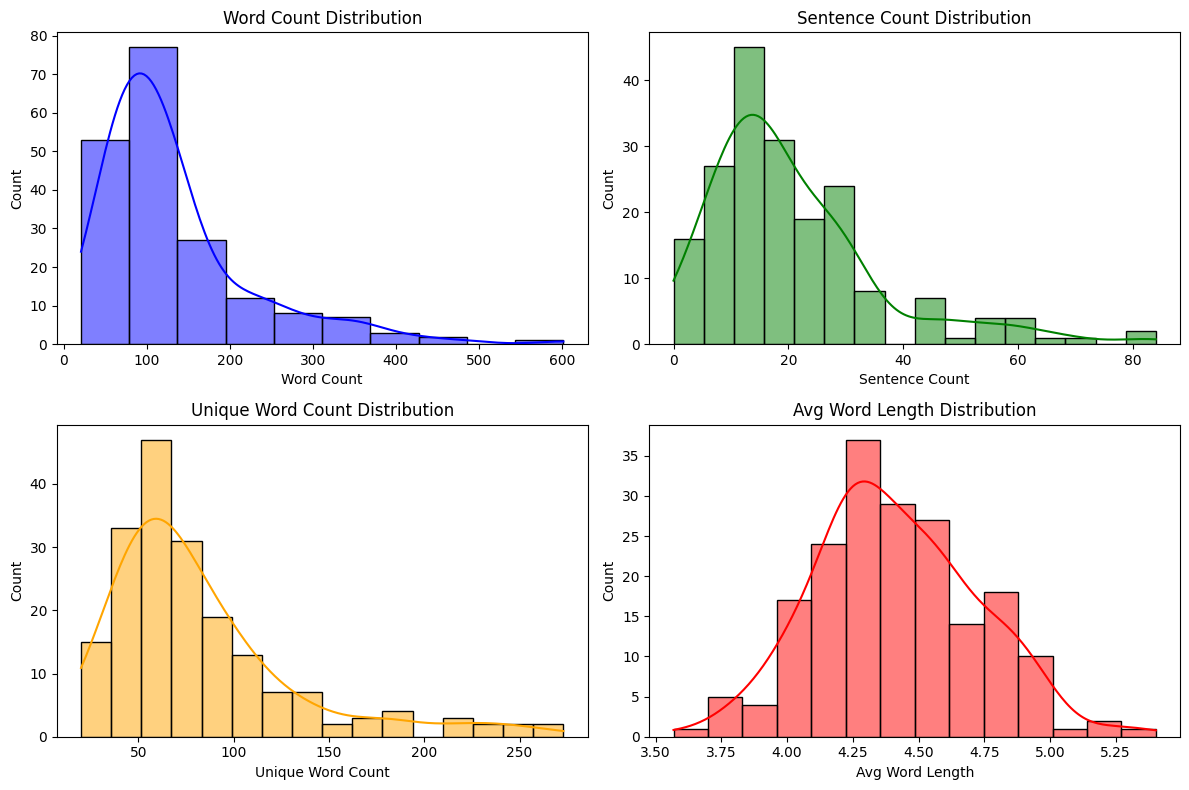

,Word Count,Sentence Count,Unique Word Count,Avg Word Length
count,190.000000,190.000000,190.000000,190.000000
mean,133.589474,20.752632,82.489474,4.412805
std,92.911290,15.174361,49.234859,0.311948
min,21.000000,0.000000,20.000000,3.568182
25%,73.000000,11.000000,51.500000,4.219044
50%,105.500000,16.000000,67.500000,4.390524
75%,146.750000,27.000000,97.000000,4.612483
max,602.000000,84.000000,273.000000,5.402778


In [8]:


# Summary Statistics
summary_stats = df.describe()

# Correlation Analysis
correlation_matrix = df[features].corr()

# Visualizations
plt.figure(figsize=(12, 8))
# Distribution of each feature
plt.subplot(2, 2, 1)
sns.histplot(df['Word Count'], kde=True, color='blue',bins=10)
plt.title('Word Count Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df['Sentence Count'], kde=True, color='green')
plt.title('Sentence Count Distribution')

plt.subplot(2, 2, 3)
sns.histplot(df['Unique Word Count'], kde=True, color='orange')
plt.title('Unique Word Count Distribution')

plt.subplot(2, 2, 4)
sns.histplot(df['Avg Word Length'], kde=True, color='red')
plt.title('Avg Word Length Distribution')

plt.tight_layout()
plt.show()

summary_stats


# Write summary talk about each feature and their distribution
* Word Count
    * The mean of the Word Count is 133.59, but there are also an outliers that has 602 words and 21 words
    * The data show that the std are around 92 which mean that most document has the word around 100-150 words
    * The 25 percentile and 75 percentile show that most entries fall within this range.
* Sentence Count
    * The mean of Sentence Count is 20.75 and std of 15.17
    * The distribution is on a right-skewed 
* Unique Word Count
    * The mean of Unique Word is 82.48 and std is 49.234
    * The range is really wide from the min is 20 and max is 273
* Avg Word Length
    * The distribution is relatively symmetric, as the mean and median are close, indicating a balanced spread of word lengths.

In [9]:
df = pd.DataFrame(data, columns=["Country", "Anthem"])

In [11]:
from deep_translator import GoogleTranslator

thai_translated = df['Anthem'].apply(lambda x: GoogleTranslator(source='en', target='th').translate(x))

print(thai_translated)


0      เราสามัคคีกันยืนหยัดอยู่รอบธงของเรา ด้วยความปร...
1      ปิตุภูมิของเรา อิสระและเป็นอิสระ ซึ่งดำรงอยู่ม...
2      ดินแดนแห่งขุนเขา ดินแดนริมแม่น้ำ ดินแดนแห่งทุ่...
3      อาเซอร์ไบจาน อาเซอร์ไบจาน! ปิตุภูมิอันรุ่งโรจน...
4      พวกเราชาวเบลารุสเป็นคนรักสันติและทุ่มเทให้กับม...
                             ...                        
185    โอ้ผู้ปกป้องบ้านเกิดเมืองนอน! รวมตัวกันเพื่อสง...
186    โอ้ ยูกันดา ขอพระเจ้าทรงค้ำจุนท่าน เราฝากอนาคต...
187    โอ้ลูกหลานของซาฮารา! ในสนามรบ พวกเจ้าเป็นผู้ถื...
188    ยืนขึ้นและร้องเพลงเกี่ยวกับแซมเบีย ดินแดนแห่งค...
189    โอ้ โปรดชูธงขึ้นสูง ธงซิมบับเว สัญลักษณ์แห่งอิ...
Name: Anthem, Length: 190, dtype: object


In [13]:
df['translated_anthem'] = thai_translated

In [ ]:
df['tokens'] = thai_translated.apply(lambda x: ' '.join(deepcut.tokenize(x)))


c:\Users\user\miniconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\user\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
30/30 ━━━━━━━━━━━━━━━━

In [ ]:

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(df['tokens'])
tfidf_thai_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

print(tfidf_thai_df)


      20  amjad  and  awice  ayia  bouill  capotillo  castile  cipe  ciuszko  \
0    0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   
1    0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   
2    0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   
3    0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   
4    0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   
..   ...    ...  ...    ...   ...     ...        ...      ...   ...      ...   
185  0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   
186  0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   
187  0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   
188  0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   
189  0.0    0.0  0.0    0.0   0.0     0.0        0.0      0.0   0.0      0.0   

     ...       ไหล  ไหลร  ไหลเว  ไหว   

In [16]:
df.to_csv('resources/anthems_translated.csv', index=False)

# Scaling using standard scalar

In [17]:
scaler = StandardScaler()
scaled_thai_tf_idf = scaler.fit_transform(tfidf_thai_df)

# K-Means Modelling


c:\Users\user\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

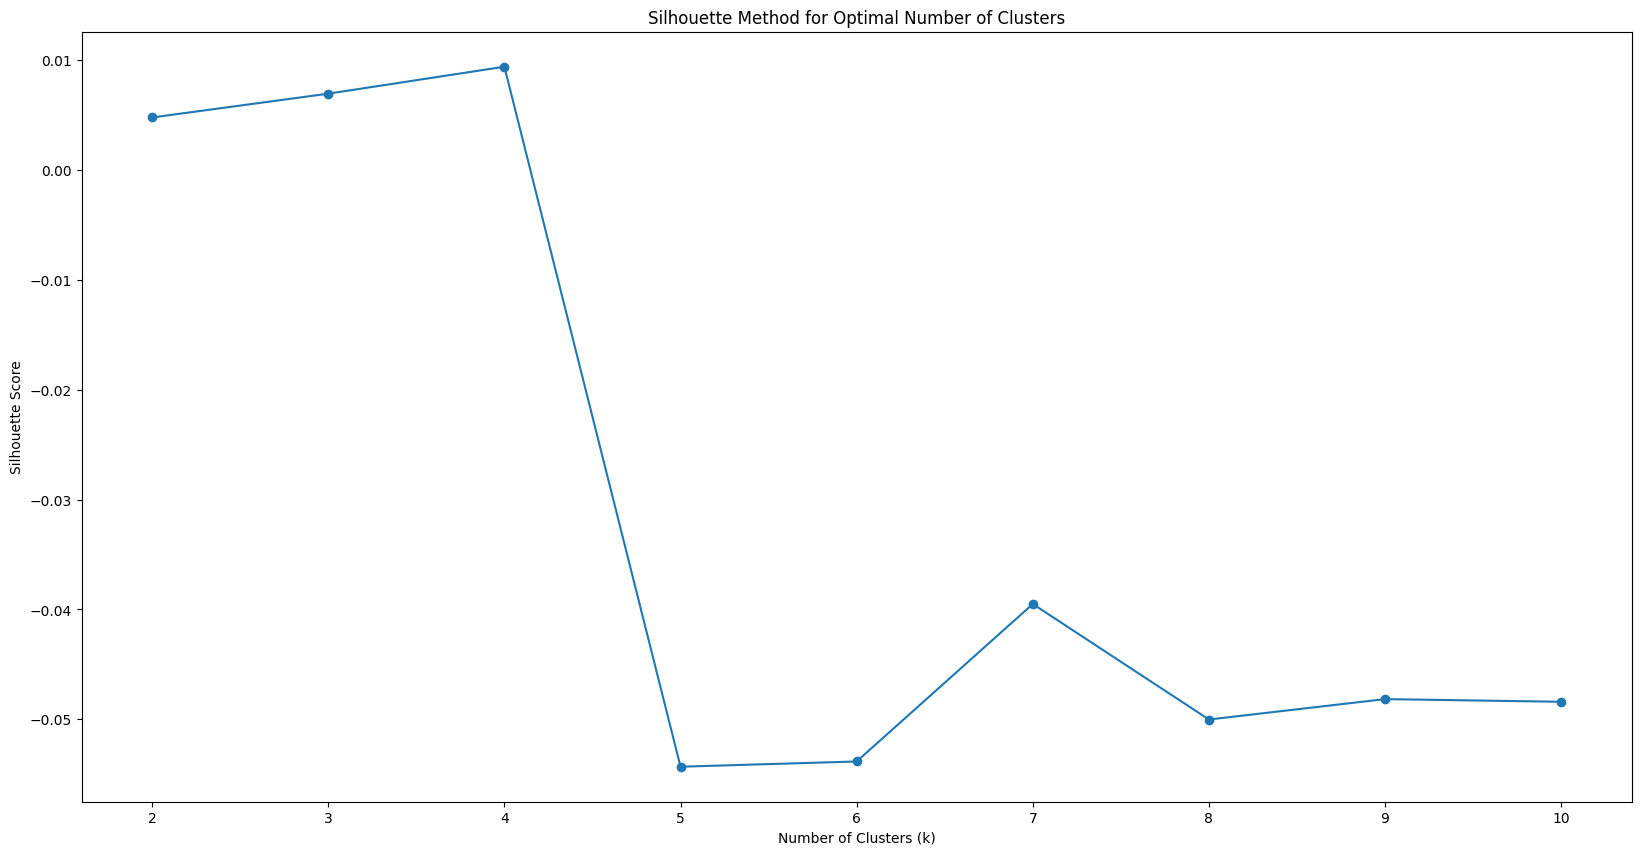

Optimal number of clusters (k) based on Silhouette Score: 4
silhouette_score: 0.009405261247931795


c:\Users\user\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
silhouette_scores = []  

for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_labels = kmeans.fit_predict(scaled_thai_tf_idf) 
    score = silhouette_score(scaled_thai_tf_idf, kmeans_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(20, 10))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2 
print(f"Optimal number of clusters (k) based on Silhouette Score: {optimal_k}")
print(f"silhouette_score: {max(silhouette_scores)}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_thai_tf_idf)

# Add the KMeans cluster labels to the DataFrame
scaled_thai_tf_idf_df = pd.DataFrame(scaled_thai_tf_idf, columns=tfidf_thai_df.columns[:scaled_thai_tf_idf.shape[1]])
scaled_thai_tf_idf_df['KMeans_Cluster'] = kmeans_labels


# HAC Modelling



In [ ]:
k_range = range(2, 11)

best_k = 0
best_score = -1 
for k in k_range:
    hierarchical = AgglomerativeClustering(n_clusters=k)
    hierarchical_labels = hierarchical.fit_predict(scaled_thai_tf_idf_df)
    
   
    score = silhouette_score(scaled_thai_tf_idf_df, hierarchical_labels)
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"Optimal number of clusters (k): {best_k}")
print(f"Silhouette Score: {best_score}")

Optimal number of clusters (k): 2
Silhouette Score: 0.3663639372989213


# Discussing

- At first I use DeepTranslator from Google to translate 'Anthem' Column from English to Thai Language and add it to translated column
- Then I use the DeepCut module to tokenize each Thai word in the translated column
- Vectorized each word from the Deepcut using TfidfVectorizer
- Then use StandardScaler to normalize the the score from TfidfVectorizer
- Modeling the K-means and HAC
- I found that when you use the Elbow method and Dendogram, it's hard to find the optimal k
- instead of using Elbow Method and Dendogram I use Silhouette_scores instead to find the optimal method
- the sillouette score just acceptable in the HAC but in the K-means it's poor clustering that's mean it cannot find the optimal k

# Ploting Elbow Method and Dendogram

c:\Users\user\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

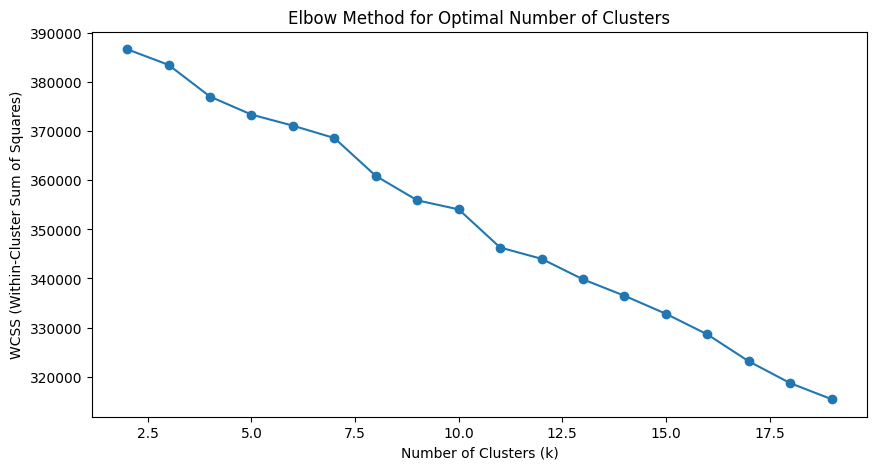

In [23]:
wcss = [] 

for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_thai_tf_idf)  
    wcss.append(kmeans.inertia_) 

plt.figure(figsize=(10, 5))
plt.plot(range(2, 20), wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

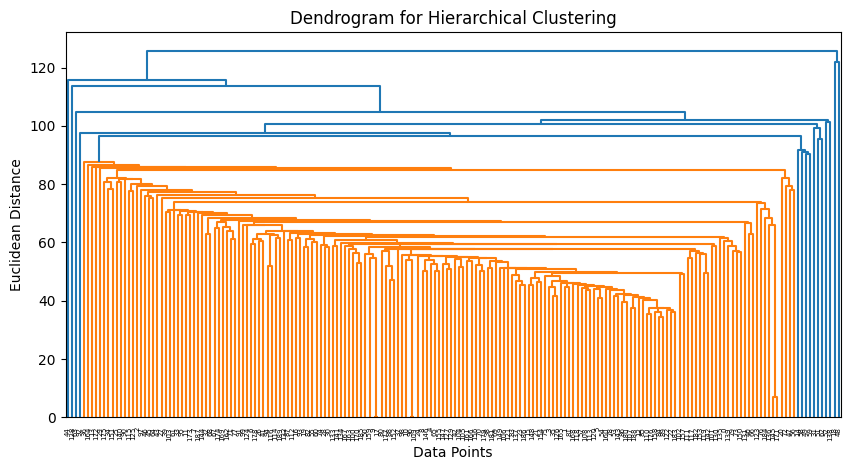

In [21]:
linkage_matrix = sch.linkage(scaled_thai_tf_idf_df, method='ward')

plt.figure(figsize=(10, 5))
sch.dendrogram(linkage_matrix)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()